In [16]:
import cv2
import numpy as np

# Load the source and destination images
src = cv2.imread('images/Cat.jpeg')  # More alpha, more source
dst = cv2.imread('images/Dog.jpeg')

# Resize both images to 1024x768
target_size = (1024, 768)
src = cv2.resize(src, target_size)
dst = cv2.resize(dst, target_size)

# Loop through alpha values from 0.01 to 1.00
for alpha in np.linspace(0.01, 1.0, 100):
    blended = cv2.addWeighted(src, alpha, dst, 1 - alpha, 0)

    # Display the blended image for 200ms
    cv2.imshow('Blended Image', blended)
    cv2.waitKey(200)
    cv2.destroyAllWindows()

    # Save only at specific alpha values
    if round(alpha, 2) in [0.25, 0.5, 0.75]:
        filename = f'blended_alpha_{alpha:.2f}.jpg'
        cv2.imwrite(filename, blended)
        print(f'Saved: {filename}')

# Final cleanup
cv2.destroyAllWindows()

Saved: blended_alpha_0.25.jpg
Saved: blended_alpha_0.50.jpg
Saved: blended_alpha_0.75.jpg


Solutions to making blending transitions smoother:

Smaller Alpha Increments in Loop
Instead of jumping directly to 0.25, 0.5, and 0.75, we can use smaller steps (e.g., 0.01) to create a smoother transition.

Gaussian Blur Before Blending
Slightly blurring images before blending can reduce harsh edges and make the transition appear more natural.

C:\Users\shbar\AppData\Local\Temp\ipykernel_20908\2564302843.py:32: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(original.ravel(), 256, [0, 256])
C:\Users\shbar\AppData\Local\Temp\ipykernel_20908\2564302843.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(equalized.ravel(), 256, [0, 256])


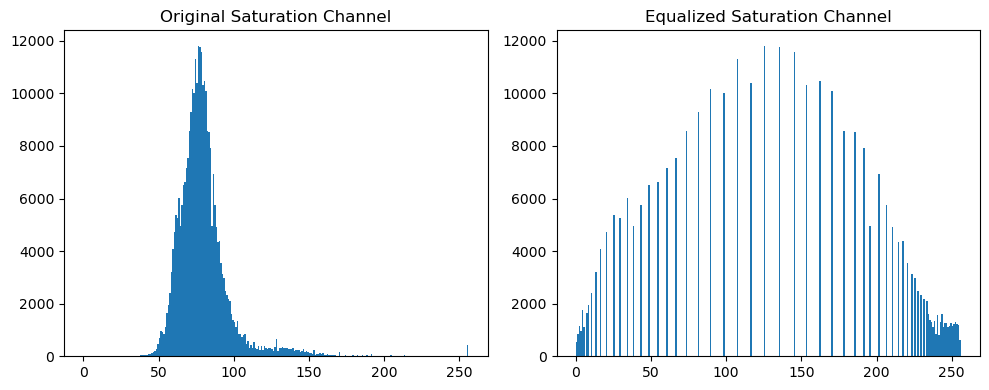

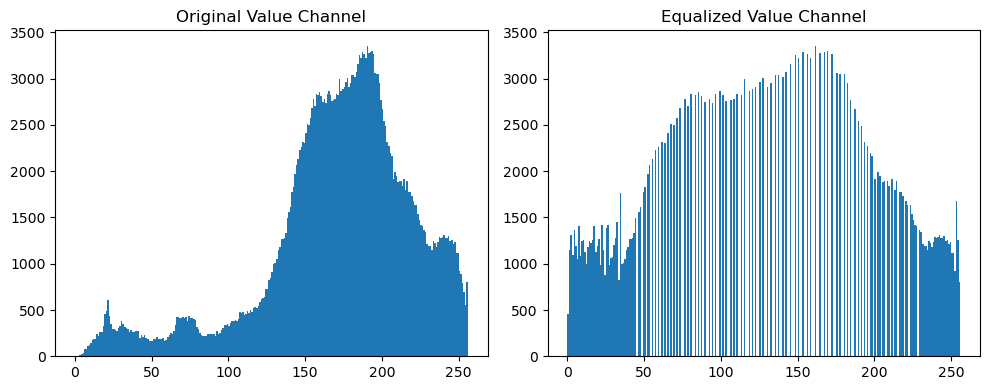

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread('images/NailPolish.jpg')

# Convert to HSV color space
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

# Equalize Saturation channel
s_eq = cv2.equalizeHist(s)
hsv_s_eq = cv2.merge([h, s_eq, v])
img_s_eq = cv2.cvtColor(hsv_s_eq, cv2.COLOR_HSV2BGR)

# Equalize Value channel
v_eq = cv2.equalizeHist(v)
hsv_v_eq = cv2.merge([h, s, v_eq])
img_v_eq = cv2.cvtColor(hsv_v_eq, cv2.COLOR_HSV2BGR)

# Display the equalized images
cv2.imshow('Equalized Saturation', img_s_eq)
cv2.imshow('Equalized Value', img_v_eq)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Plot histograms
def plot_histogram(original, equalized, title):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(original.ravel(), 256, [0, 256])
    plt.title(f'Original {title}')
    plt.subplot(1, 2, 2)
    plt.hist(equalized.ravel(), 256, [0, 256])
    plt.title(f'Equalized {title}')
    plt.tight_layout()
    plt.show()

plot_histogram(s, s_eq, 'Saturation Channel')
plot_histogram(v, v_eq, 'Value Channel')
